In [1]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


# Multivariate analysis: Modeling

![](https://media.geeksforgeeks.org/wp-content/uploads/20240919170522/supervised-vs-reinforcement-vs-unsupervised.webp)

![](https://docs.microsoft.com/en-us/azure/machine-learning/team-data-science-process/media/overview/tdsp-lifecycle2.png "Data Science Lifecycle")

Interesting sources: 
- https://learn.datacamp.com/courses/machine-learning-with-tree-based-models-in-python
- https://www.datacamp.com/community/tutorials/decision-tree-classification-python

We have seen that we can uncover correlations by using bivariate analyis. This also raises the question: If we extract information from multiple columns (Multivariate analysis), could we use these correlations to calculate/predict the value of a column for rows that do not yet have a value?

For example:
- Can we calculate if a customer will churn (= We lose the customer)?
- Can we calculate if a customer would use a certain product? (Product recommendation)
- Can we calculate if a mail is spam or not?
- Can we calculate if a financial transaction is fraudulent or not?
- Can we calculate if a customer will be able to pay back their loan or not?
- Can we calculate the price people are willing to pay for a house?
- Can we calculate the salary a student will earn in the future?
- ...

Just as we used math/statistics to support to explore the data one column at a time (Univariate) and per combination of two columns (Bivariate analysis), we will use machine learning algorithms to extract information across multiple columns (Multivariate analysis) and to build data products. 

Machine learning is:
- Machine learning is a method of data analysis that automates analytical model building. It is a branch of artificial intelligence based on the idea that systems can learn from data, identify patterns and make decisions with minimal human intervention. (https://www.sas.com/en_us/insights/analytics/machine-learning.html#:~:text=Machine%20learning%20is%20a%20method,decisions%20with%20minimal%20human%20intervention.)
- Machine learning (ML) is the study of computer algorithms that improve automatically through experience.[1] It is seen as a part of artificial intelligence. Machine learning algorithms build a model based on sample data, known as "training data", in order to make predictions or decisions without being explicitly programmed to do so.[2] Machine learning algorithms are used in a wide variety of applications, such as email filtering and computer vision, where it is difficult or unfeasible to develop conventional algorithms to perform the needed tasks. (https://en.wikipedia.org/wiki/Machine_learning)

Examples of data products could include:
- A product recommender
- A customer churn predictor
- A mail labeler (Primary, promotion, social, spam, etc.)
- Sentiment analyser for social media messages
- ...

![](https://miro.medium.com/max/1204/1*qYoU2VTBsORAfhkfiluURQ.png)

We will refer to the column that we are trying to calculate as the <b>target variable</b>. The columns used for this calculation will be refered to as the <b>feature variables</b>.

For example, if we want to predict a person's shoe size based on their body length:
- The shoe size is the target variable
- The body length is the feature variable

Extra info: The terms 'target' and 'feature' are borrowed from the field of Machine Learning. In the field of statistics, we refer to the target variable as the dependent variable and we refer to the feature variables as the independent variables.

# Classification

When the target variable is a categorical variable then we refer to this task as a classification task.

Examples of classification tasks:
- Predict if a customer will churn. 
- Predict if a customer will use a specific product.
- Label mails as spam.
- Label financial transactions as fraudulent.
- Label a social media message as positive, neutral or negative.
- Predict if a customer of the bank will be able to pay back the loan.

Examples of machine learning algorithms that we could use for classification:
- Decision trees
- Random forests
- Logistic regression
- Neural networks
- Naive bayes

In [21]:
import seaborn as sns
import pandas as pd

iris = sns.load_dataset("iris")
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


![](https://miro.medium.com/max/1000/1*Hh53mOF4Xy4eORjLilKOwA.png "Iris dataset") 

## Training the model

In [3]:
from sklearn.tree import DecisionTreeClassifier

In [22]:
features= ['sepal_length', 'petal_length']
dt = DecisionTreeClassifier(max_depth = 4) # Increase max_depth to see effect in the plot
dt.fit(iris[features], iris['species'])

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


This Python code trains a **Decision Tree Classifier** on a subset of the famous Iris dataset, using only two features: 'sepal_length' and 'petal_length'. **Only these will be used to train the model**. It creates a decision tree classifier with a **maximum depth of 5**, meaning the tree will be allowed to split at most 5 times from the root to a leaf. This limits its complexity and helps prevent overfitting.

It trains (fits) the decision tree on the selected features and the **target label 'species'**. It learns to classify the type of Iris flower (setosa, versicolor, virginica) based on 'sepal_length' and 'petal_length'.


`conda install -c anaconda graphviz`  
`conda install -c anaconda python-graphviz`  
`conda install -c anaconda pydot`  
If the code below still does not work, install from here: (https://graphviz.org/download/) 

Make sure you select 'Add to path' when installing or add it afterwards.

In [14]:
pip install graphviz

Note: you may need to restart the kernel to use updated packages.


In [15]:
from sklearn import tree
import graphviz

def plot_tree_classification(model, features, class_names):
    # Generate plot data
    dot_data = tree.export_graphviz(model, out_file=None, 
                          feature_names=features,  
                          class_names=class_names,  
                          filled=True, rounded=True,  
                          special_characters=True)  

    # Turn into graph using graphviz
    graph = graphviz.Source(dot_data)  

    # Write out a pdf
    graph.render("decision_tree")

    # Display in the notebook
    return graph 

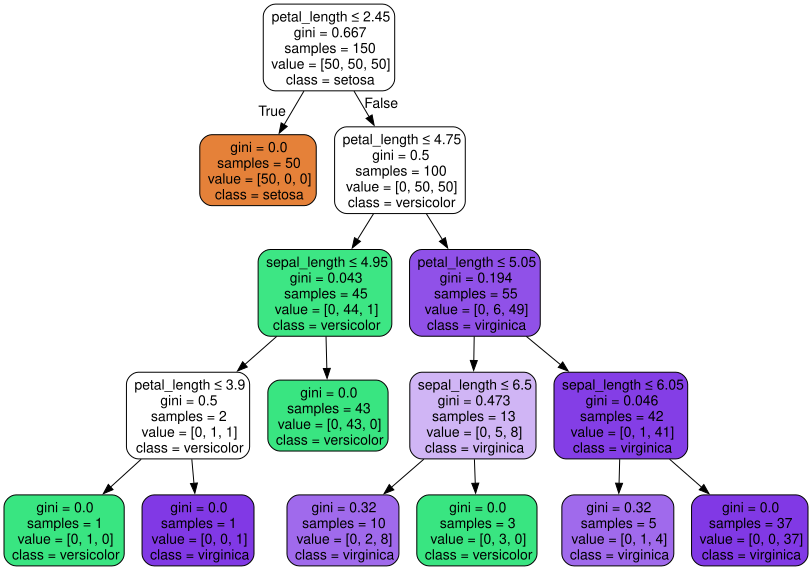

In [18]:
import numpy as np
plot_tree_classification(dt, features, np.sort(iris.species.unique()))

**What do you see here?**

Let's take a look at the first node:

samples = 150: all samples from the dataset.
value = [50, 50, 50]: 50 samples each from setosa, versicolor, and virginica.
gini = 0.667: high impurity (which makes sense, since the classes are perfectly balanced).
petal_length ≤ 2.45: this is the first split criterion.

class = the predicted class.
The class with the highest number of samples at that node.
But at the first node, all classes are equally represented ([50, 50, 50]), so technically the model is just picking one arbitrarily — probably the first in lexicographic order, which is: setosa, versicolor, virginica
So, it's not a prediction, just a default label when there's a tie.


## Evaluating the model

In [19]:
predictions = dt.predict(iris[features])

In [9]:
predictions

array(['setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'versicolor', 'versicolor', 'virginica',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'virginica', 'versicolor', 'virginica', 'versicolor',
       'versicolor', 'versicolor', 'virginica', 'virginica', 'versico

**What this does:**

It uses your trained decision tree model (dt) to make predictions on the dataset iris[features], which contains only the two features:
'sepal_length' and 'petal_length'.

**🧠 What kind of predictions?**

The model outputs the predicted species (e.g., 'setosa', 'versicolor', 'virginica') for each row in the dataset — based on the decision rules it learned during training.

In [30]:
def calculate_accuracy(predictions, actuals):
    if(len(predictions) != len(actuals)):
        raise Exception("The amount of predictions did not equal the amount of actuals")
    
    return (predictions == actuals).sum() / len(actuals)

In [29]:
calculate_accuracy(predictions, iris.species)

np.float64(0.98)

This function **calculate_accuracy(predictions, actuals)** computes the classification accuracy of your model's predictions compared to the actual (true) labels.

### Test/train split

In [32]:
from sklearn.model_selection import train_test_split

In [33]:
iris_train, iris_test = train_test_split(iris, test_size=0.3, random_state=42, stratify=iris['species'])
print(iris_train.shape, iris_test.shape)

(105, 5) (45, 5)


**Why Test/Train split?**

Splitting the dataset allows you to train the model on one part (training set) and evaluate it on another (test set).
This helps you simulate how the model performs on unseen, real-world data. It prevents **overfitting**, where the model memorizes the training data but fails on new data.

The **stratify** option ensures that each class is proportionally represented in both the training and test sets. This is important for balanced model training and fair evaluation.
**random_state ensures reproducibility**, so you get the same split each time you run the code.
**A 70/30 split (test_size=0.3)** is a common and balanced choice for small datasets like Iris.

In [37]:
features= ['sepal_length', 'sepal_width']
dt_classification = DecisionTreeClassifier(max_depth = 5) # Increase max_depth to see effect in the plot
dt_classification.fit(iris_train[features], iris_train['species'])

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### Overfitting

In [38]:
predictionsOnTrainset = dt_classification.predict(iris_train[features])
predictionsOnTestset = dt_classification.predict(iris_test[features])

accuracyTrain = calculate_accuracy(predictionsOnTrainset, iris_train.species)
accuracyTest = calculate_accuracy(predictionsOnTestset, iris_test.species)

print("Accuracy on training set " + str(accuracyTrain))
print("Accuracy on test set " + str(accuracyTest))

Accuracy on training set 0.8571428571428571
Accuracy on test set 0.7333333333333333


**Results Summary**

Training Accuracy: 83.8%
Test Accuracy: 73.3%

**What this means**

Your model performs reasonably well on the training data.
The lower test accuracy suggests the model is not generalizing perfectly to unseen data.
The ~10% drop in accuracy is a sign of mild overfitting — the model may have learned some patterns specific to the training data that don't hold in the test set.

### Saving your model

Training a machine learning model can be a time-consuming process—sometimes taking hours or even days—especially when working with large datasets. Once the model is trained and ready for production, it's inefficient and unnecessary to retrain it every time new data becomes available. To address this, we typically save the trained model to a file so it can be reused later without retraining. This is known as model serialization. There are several tools available for this purpose, such as joblib, pickle, or plk (short for .pltk format). In this case, we use the .pltk format to store the trained model, which allows us to quickly load and deploy it whenever needed.

In [39]:
import pickle

# Save the model
with open('Decisiontree_95%.pkl', 'wb') as f:
    pickle.dump(dt_classification, f)

## Portfolio assignment 15
30 min: Train a decision tree to predict the species of a **penguin** based on their characteristics.
- Prepare the data:
    - <b>Note</b>: Some machine learning algorithms can not handle missing values. You will either need to: 
         - replace missing values (with the mean or most popular value). For replacing missing values you can use .fillna(\<value\>) https://pandas.pydata.org/docs/reference/api/pandas.Series.fillna.html
         - remove rows with missing data.  You can remove rows with missing data with .dropna() https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.dropna.html
- Split the penguin dataset into a train (70%) and test (30%) set.
- Use the train set to fit a DecisionTreeClassifier. You are free to to choose which columns you want to use as feature variables and you are also free to choose the max_depth of the tree. 
- Use your decision tree model to make predictions for both the train and test set.

In [ ]:
penguins = sns.load_dataset("penguins")
penguins.head()

![](https://i.imgur.com/0v1CGNV.png)<br>
- Calculate the accuracy for both the train set predictions and test set predictions
- Is the accurracy different? Did you expect this difference?
- Use the plot_tree_classification function above to create a plot of the decision tree. Take a few minutes to analyse the decision tree. Do you understand the tree?
- Which depth and features did you add per cycle?
- Optional: Perform the same tasks but try to predict the sex of the pinguin based on the other columns<br>
<br>

Findings: ...

## Portfolio assignment 16
30 min: Train a decision tree to predict one of the categorical columns of your **own** dataset.
- Prepare the data:<br>
    - <b>Note</b>: Some machine learning algorithms can not handle missing values. You will either need to: 
         - replace missing values (with the mean or most popular value). For replacing missing values you can use .fillna(\<value\>) https://pandas.pydata.org/docs/reference/api/pandas.Series.fillna.html
         - remove rows with missing data.  You can remove rows with missing data with .dropna() https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.dropna.html <br>
- Split your dataset into a train (70%) and test (30%) set.
- Use the train set to fit a DecisionTreeClassifier. You are free to to choose which columns you want to use as feature variables and you are also free to choose the max_depth of the tree. 
- Use your decision tree model to make predictions for both the train and test set.<br>
<br>
    
![](https://i.imgur.com/0v1CGNV.png)<br>
- Calculate the accuracy for both the train set predictions and test set predictions.
- Is the accurracy different? Did you expect this difference?
- Use the plot_tree function above to create a plot of the decision tree. Take a few minutes to analyse the decision tree. Do you understand the tree?
- Which depth and features did you add per cycle?<br>
<br>

Findings: ...

# Regression

When the target variable is a numerical variable then we refer to this task as a regression task.

Examples of regression tasks:
- Predict the price people are willing to pay for a house.
- Predict the salary a student will earn in the future.

Examples of machine learning algorithms that we could use for regression:
- Linear regression
- Decision trees
- Random forests
- Neural networks

In [ ]:
iris.corr(numeric_only=True) # to find out which features  correlate with sepal_length

In [ ]:
from sklearn.tree import DecisionTreeRegressor

In [ ]:
features= ['petal_length'] # add 'petal_width' ('species' does not work; categorical is not implemented in DT of sciki learn)
dt_regression = DecisionTreeRegressor(max_depth = 2) # Increase max_depth to see effect in the plot
dt_regression.fit(iris_train[features].values, iris_train['sepal_length'].values)

In [ ]:
#visualisation in a scatterplot how a decision tree regressor makes his decisions
import matplotlib.pyplot as plt

X_train=iris_train[features].values                     # Assign matrix X
y_train=iris_train['sepal_length'].values               # Assign matrix y

sort_idx = X_train.flatten().argsort()                  # Sort X and y by ascending values of X
X_train = X_train[sort_idx]
y_train = y_train[sort_idx]

plt.figure(figsize=(16, 8))
plt.scatter(X_train, y_train, c='steelblue',                  # Plot actual target against features
            edgecolor='white', s=70)
plt.plot(X_train, dt_regression.predict(X_train),                      # Plot predicted target against features
         color='red', lw=2)
plt.xlabel('petal_length')
plt.ylabel('sepal_length')
plt.show()

In [ ]:
pip install dtreeviz

In [ ]:
import dtreeviz
viz_rmodel = dtreeviz.model(dt_regression, X_train, y_train,
                            feature_names=features,
                            target_name='sepal_length')
viz_rmodel.rtree_feature_space(features=features)

In [ ]:
from sklearn import tree
import graphviz

def plot_tree_regression(model, features):
    # Generate plot data
    dot_data = tree.export_graphviz(model, out_file=None, 
                          feature_names=features,  
                          filled=True, rounded=True,  
                          special_characters=True)  

    # Turn into graph using graphviz
    graph = graphviz.Source(dot_data)  

    # Write out a pdf
    graph.render("decision_tree")

    # Display in the notebook
    return graph 

In [ ]:
plot_tree_regression(dt_regression, features)

## Evaluating the model

![](https://docs.oracle.com/en/cloud/saas/freeform/ffuuu/img/insights_rmse_formula.jpg)

In [ ]:
def calculate_rmse(predictions, actuals):
    if(len(predictions) != len(actuals)):
        raise Exception("The amount of predictions did not equal the amount of actuals")
    
    return (((predictions - actuals) ** 2).sum() / len(actuals)) ** (1/2)

In [ ]:
predictionsOnTrainset = dt_regression.predict(iris_train[features])
predictionsOnTestset = dt_regression.predict(iris_test[features])

rmseTrain = calculate_rmse(predictionsOnTrainset, iris_train.sepal_length)
rmseTest = calculate_rmse(predictionsOnTestset, iris_test.sepal_length)

print("RMSE on training set " + str(rmseTrain))
print("RMSE on test set " + str(rmseTest))

✅ How to interpret this:
Root Mean Squared Error (RMSE) gives the average prediction error in the same units as your target variable (here: sepal_length, measured in cm).

An RMSE of ~0.46 cm means your model's average error on the test set is less than half a centimeter — quite acceptable, given that sepal_length values range roughly between 4.3 and 7.9 cm in the Iris dataset.

The small gap between train and test RMSE also indicates low overfitting and good generalization.

📌 Rule of thumb:
To judge whether RMSE is "good", compare it to:

The range or standard deviation of the target variable.
A baseline model, like predicting the mean sepal length for every sample.

## Portfolio assignment 17
30 min: Train a decision tree to predict the body_mass_g of a penguin based on their characteristics.
- Split the penguin dataset into a train (70%) and test (30%) set.
- Use the train set to fit a DecisionTreeRegressor. You are free to to choose which columns you want to use as feature variables and you are also free to choose the max_depth of the tree. 
<b>Note</b>: Some machine learning algorithms can not handle missing values. You will either need to 
     - replace missing values (with the mean or most popular value). For replacing missing values you can use .fillna(\<value\>) https://pandas.pydata.org/docs/reference/api/pandas.Series.fillna.html
     - remove rows with missing data.  You can remove rows with missing data with .dropna() https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.dropna.html
- Use your decision tree model to make predictions for both the train and test set.<br>
<br>

![](https://i.imgur.com/0v1CGNV.png)<br>
- Which depth and features did you add per cycle?
- Calculate the RMSE for both the train set predictions and test set predictions.
- Is the RMSE different? Did you expect this difference?
- Use the plot_tree_regression function above to create a plot of the decision tree. Take a few minutes to analyse the decision tree. Do you understand the tree?<br>
<br>

Findings: ...

In [ ]:
penguins = sns.load_dataset("penguins")
penguins.head()

## Portfolio assignment 18
30 min: Train a decision tree to predict one of the numerical columns of your own dataset.
- Split your dataset into a train (70%) and test (30%) set.
- Use the train set to fit a DecisionTreeRegressor. You are free to to choose which columns you want to use as feature variables and you are also free to choose the max_depth of the tree. 
- Use your decision tree model to make predictions for both the train and test set.<br>
<br>

![](https://i.imgur.com/0v1CGNV.png)<br>
- Which depth and features did you add per cycle?
- Calculate the RMSE for both the train set predictions and test set predictions.
- Is the RMSE different? Did you expect this difference?
- Use the plot_tree_regression function above to create a plot of the decision tree. Take a few minutes to analyse the decision tree. Do you understand the tree?<br>
<br>

Findings: ...